In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.graphics.tsaplots import plot_acf
 
TARGET        = 'pm2_5'
TIMESTAMP_COL = 'time'

data = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")
data['time'] = pd.to_datetime(data['time'])
data = data.set_index('time').sort_index()

Inferred frequency: h
Decomposition period: 24


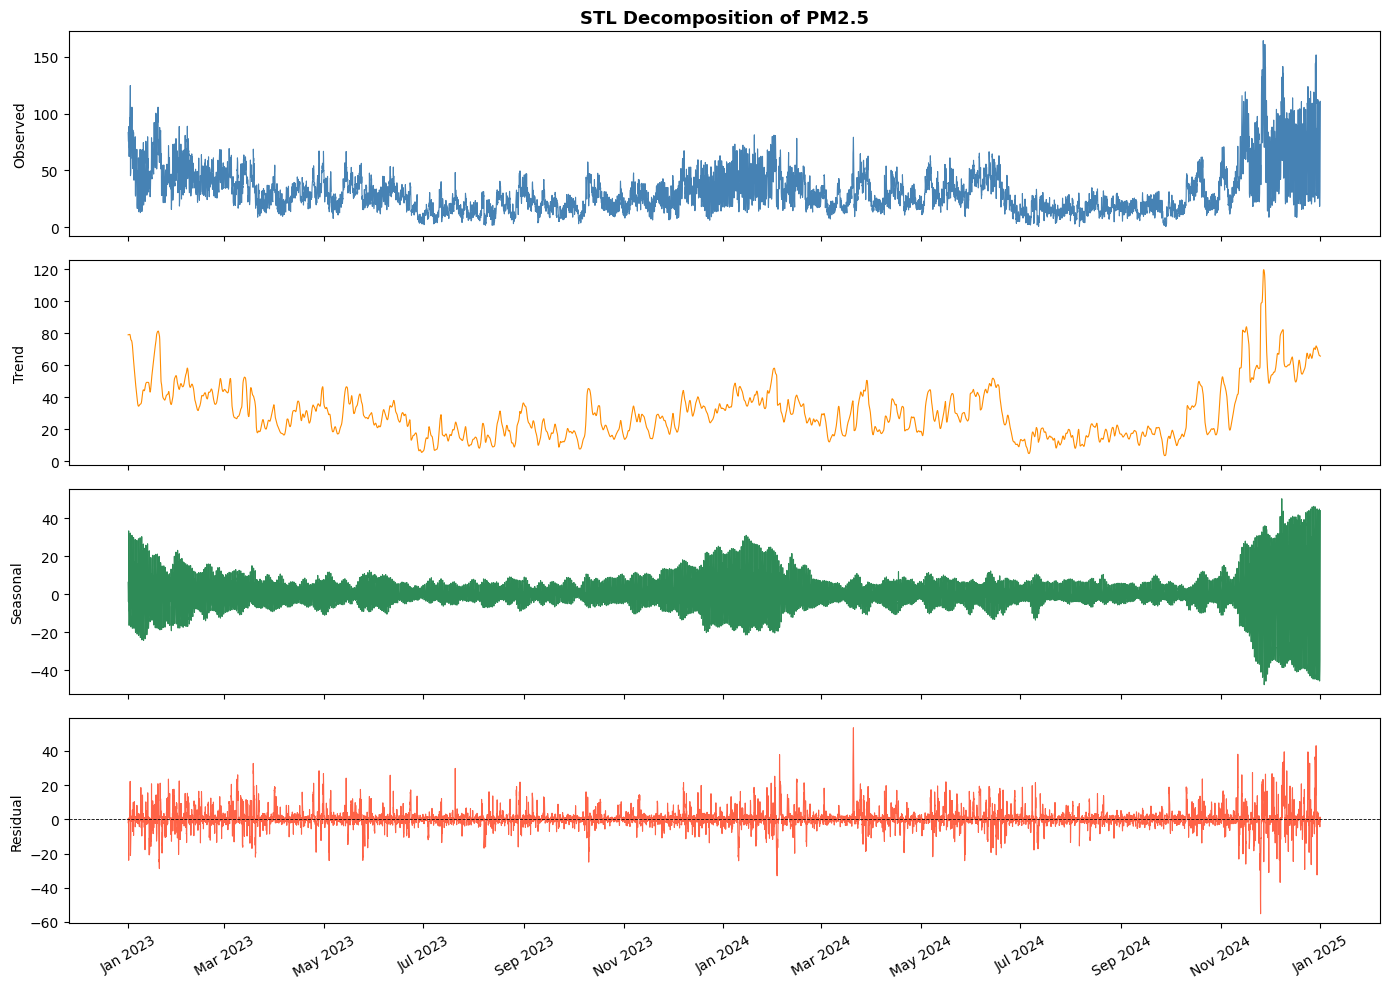

Strength of Trend    : 0.8999  (0=none, 1=strong)
Strength of Seasonal : 0.7376  (0=none, 1=strong)


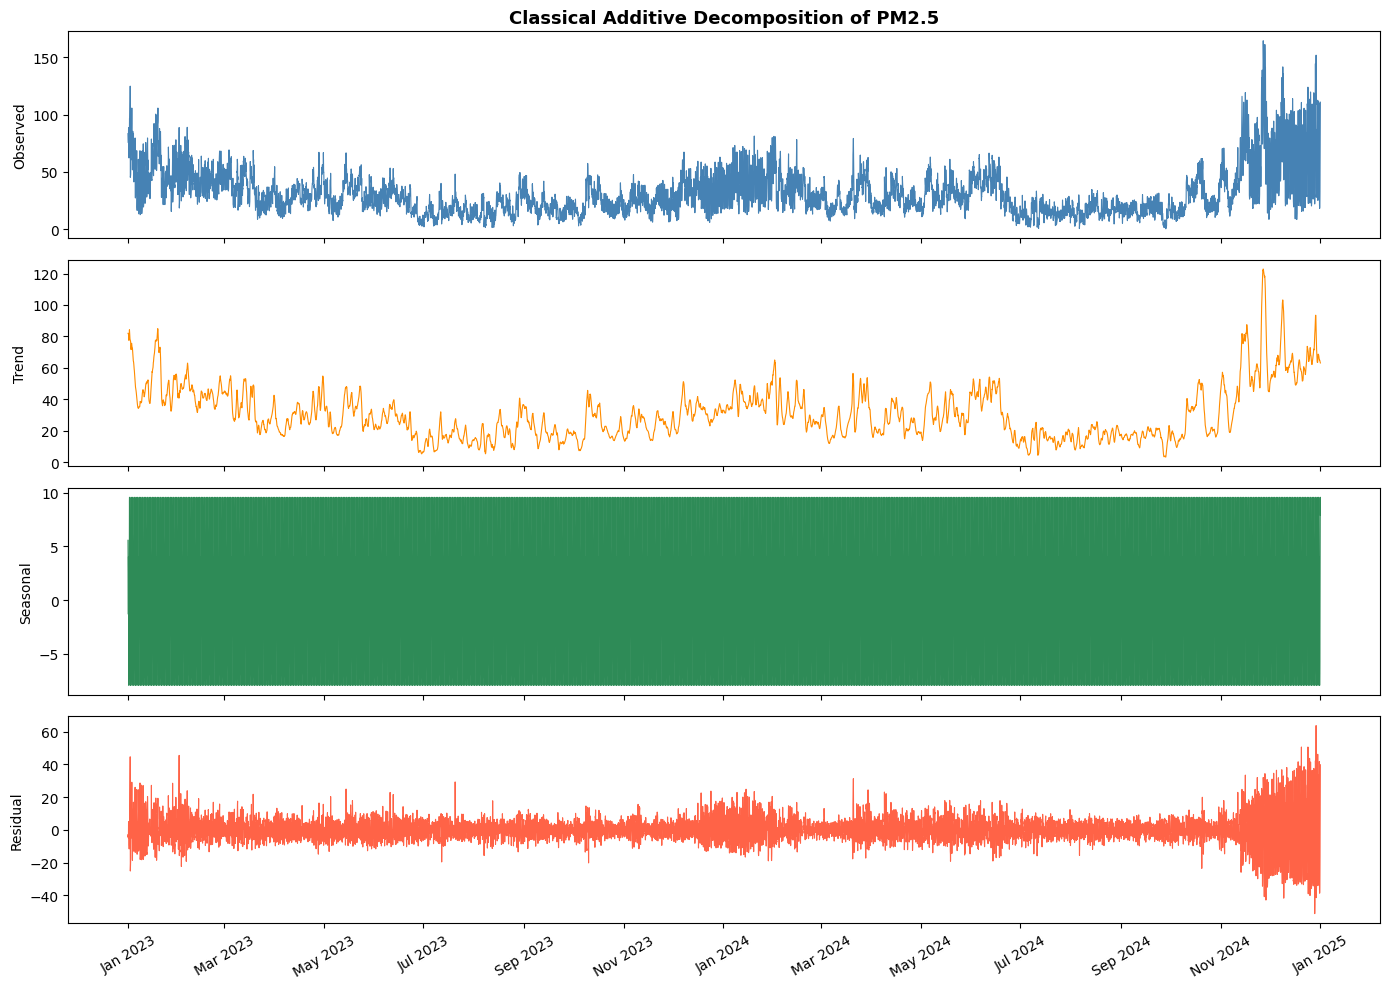

In [2]:

inferred_freq = pd.infer_freq(data.index[:50])
print(f'Inferred frequency: {inferred_freq}')

# 24 for hourly data, 7 for daily data
PERIOD = 24 if inferred_freq in ['H', 'h', '1H', '60min', 'T'] else 7
print(f'Decomposition period: {PERIOD}')

pm25_series = data[TARGET].copy()
stl        = STL(pm25_series, period=PERIOD, robust=True)
stl_result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
components = [
    (pm25_series,       'Observed', 'steelblue'),
    (stl_result.trend,  'Trend',    'darkorange'),
    (stl_result.seasonal, 'Seasonal', 'seagreen'),
    (stl_result.resid,  'Residual', 'tomato'),
]
for ax, (series, label, color) in zip(axes, components):
    ax.plot(series.index, series.values, linewidth=0.8, color=color)
    ax.set_ylabel(label, fontsize=10)
    if label == 'Residual':
        ax.axhline(0, color='black', linewidth=0.6, linestyle='--')

axes[0].set_title('STL Decomposition of PM2.5', fontsize=13, fontweight='bold')
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

var_resid = np.var(stl_result.resid)
F_trend   = max(0, 1 - var_resid / np.var(stl_result.trend   + stl_result.resid))
F_season  = max(0, 1 - var_resid / np.var(stl_result.seasonal + stl_result.resid))
print(f'Strength of Trend    : {F_trend:.4f}  (0=none, 1=strong)')
print(f'Strength of Seasonal : {F_season:.4f}  (0=none, 1=strong)')

classical = seasonal_decompose(
    pm25_series, model='additive', period=PERIOD, extrapolate_trend='freq'
)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, (series, label, color) in zip(axes, [
    (classical.observed, 'Observed', 'steelblue'),
    (classical.trend,    'Trend',    'darkorange'),
    (classical.seasonal, 'Seasonal', 'seagreen'),
    (classical.resid,    'Residual', 'tomato'),
]):
    ax.plot(series.index, series.values, linewidth=0.8, color=color)
    ax.set_ylabel(label, fontsize=10)

axes[0].set_title('Classical Additive Decomposition of PM2.5', fontsize=13, fontweight='bold')
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


── ADF Test: PM2.5 (raw) ──────────────────────────────
  Test Statistic : -5.8642
  p-value        : 0.0000
  Lags used      : 44
  Critical Values: 1%=-3.431, 5%=-2.862, 10%=-2.567
  Conclusion     : Stationary (α=0.05)

── KPSS Test: PM2.5 (raw) ──────────────────────────────
  Test Statistic : 1.4618
  p-value        : 0.0100
  Lags used      : 73
  Critical Values: 10%=0.347, 5%=0.463, 2.5%=0.574, 1%=0.739
  Conclusion     : Non-stationary (α=0.05)


C:\Users\adars\AppData\Local\Temp\ipykernel_15452\216371065.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result                             = kpss(series.dropna(), regression='c', nlags='auto')



── ADF Test: PM2.5 (1st diff) ──────────────────────────────
  Test Statistic : -29.6038
  p-value        : 0.0000
  Lags used      : 44
  Critical Values: 1%=-3.431, 5%=-2.862, 10%=-2.567
  Conclusion     : Stationary (α=0.05)

── KPSS Test: PM2.5 (1st diff) ──────────────────────────────
  Test Statistic : 0.0796
  p-value        : 0.1000
  Lags used      : 92
  Critical Values: 10%=0.347, 5%=0.463, 2.5%=0.574, 1%=0.739
  Conclusion     : Stationary (α=0.05)
        Series  ADF Stationary  KPSS Stationary
           Raw            True            False
1st Difference            True             True


C:\Users\adars\AppData\Local\Temp\ipykernel_15452\216371065.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result                             = kpss(series.dropna(), regression='c', nlags='auto')


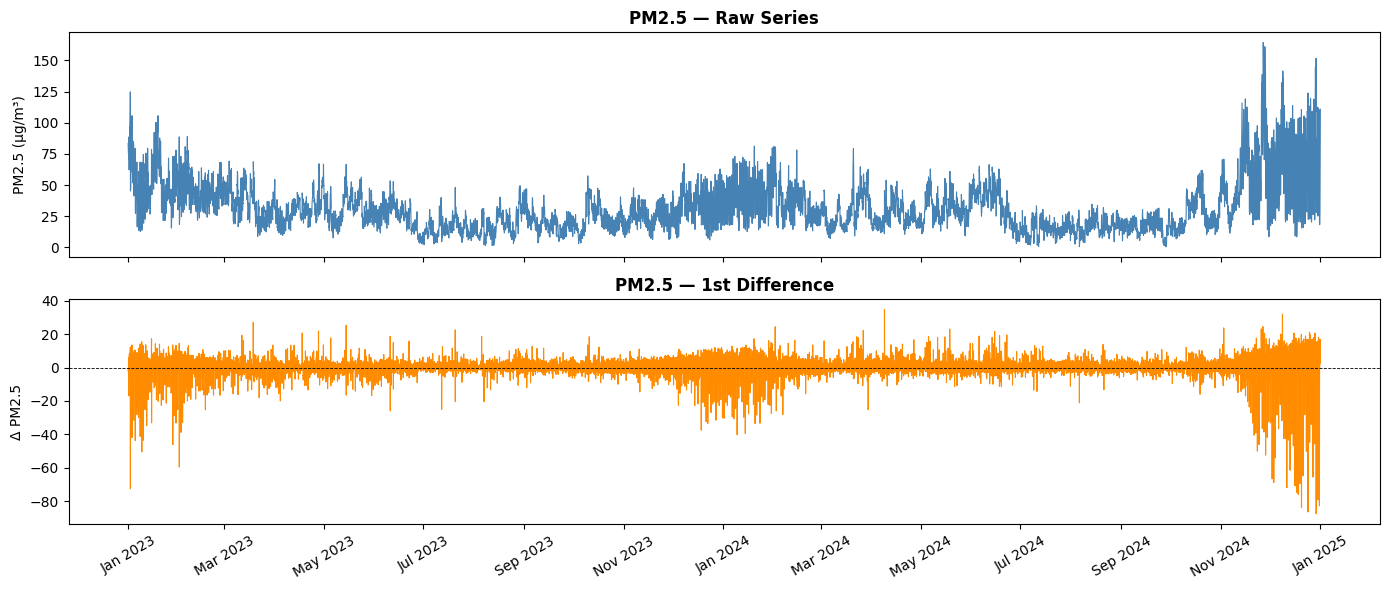

In [3]:
def run_adf(series, label='Series'):
    result                                    = adfuller(series.dropna(), autolag='AIC')
    adf_stat, p_val, n_lags, n_obs, crit_vals, _ = result
    conclusion = 'Stationary' if p_val < 0.05 else 'Non-stationary'
    print(f'\n── ADF Test: {label} ──────────────────────────────')
    print(f'  Test Statistic : {adf_stat:.4f}')
    print(f'  p-value        : {p_val:.4f}')
    print(f'  Lags used      : {n_lags}')
    print(f'  Critical Values: 1%={crit_vals["1%"]:.3f}, 5%={crit_vals["5%"]:.3f}, 10%={crit_vals["10%"]:.3f}')
    print(f'  Conclusion     : {conclusion} (α=0.05)')
    return p_val < 0.05


def run_kpss(series, label='Series'):
    result                             = kpss(series.dropna(), regression='c', nlags='auto')
    kpss_stat, p_val, n_lags, crit_vals = result
    conclusion = 'Non-stationary' if p_val < 0.05 else 'Stationary'
    print(f'\n── KPSS Test: {label} ──────────────────────────────')
    print(f'  Test Statistic : {kpss_stat:.4f}')
    print(f'  p-value        : {p_val:.4f}')
    print(f'  Lags used      : {n_lags}')
    print(f'  Critical Values: 10%={crit_vals["10%"]}, 5%={crit_vals["5%"]}, 2.5%={crit_vals["2.5%"]}, 1%={crit_vals["1%"]}')
    print(f'  Conclusion     : {conclusion} (α=0.05)')
    return p_val >= 0.05


# Test on raw series
adf_raw  = run_adf(pm25_series, 'PM2.5 (raw)')
kpss_raw = run_kpss(pm25_series, 'PM2.5 (raw)')

# Test on first-differenced series
pm25_diff = pm25_series.diff().dropna()
adf_diff  = run_adf(pm25_diff, 'PM2.5 (1st diff)')
kpss_diff = run_kpss(pm25_diff, 'PM2.5 (1st diff)')

stationarity_summary = pd.DataFrame({
    'Series'         : ['Raw', '1st Difference'],
    'ADF Stationary' : [adf_raw,  adf_diff],
    'KPSS Stationary': [kpss_raw, kpss_diff],
})

print(stationarity_summary.to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(pm25_series.index, pm25_series.values, linewidth=0.8, color='steelblue')
axes[0].set_title('PM2.5 — Raw Series', fontweight='bold')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[1].plot(pm25_diff.index, pm25_diff.values, linewidth=0.8, color='darkorange')
axes[1].axhline(0, color='black', linewidth=0.6, linestyle='--')
axes[1].set_title('PM2.5 — 1st Difference', fontweight='bold')
axes[1].set_ylabel('Δ PM2.5')
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Feature columns (10): ['pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'wind_direction_10m', 'surface_pressure']
             Feature  Pearson r       p-value Significant
                pm10   0.952177  0.000000e+00           ✓
     sulphur_dioxide   0.753975  0.000000e+00           ✓
     carbon_monoxide   0.620771  0.000000e+00           ✓
      temperature_2m  -0.522716  0.000000e+00           ✓
    nitrogen_dioxide   0.493972  0.000000e+00           ✓
    surface_pressure   0.175934 5.832987e-122           ✓
      wind_speed_10m  -0.110932  3.687389e-49           ✓
  wind_direction_10m  -0.109160  1.194951e-47           ✓
relative_humidity_2m   0.045576  1.546894e-09           ✓
               ozone  -0.019743  8.918674e-03           ✓


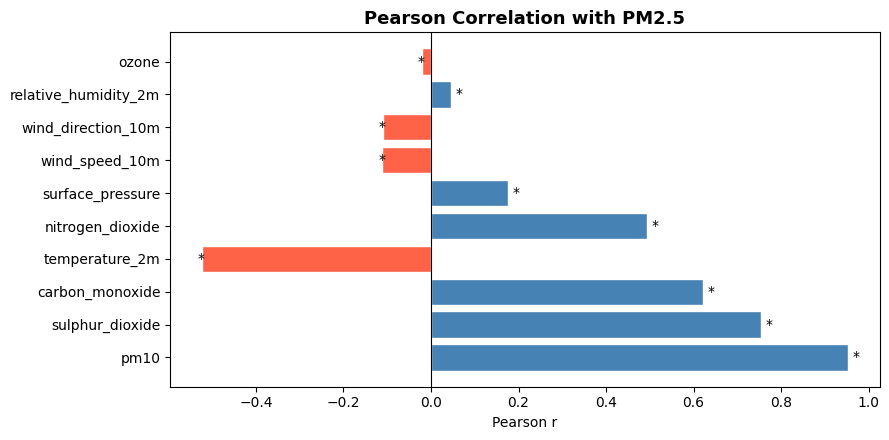

In [4]:
#PEARSON CORRELATION

feature_cols = [c for c in data.select_dtypes(include=np.number).columns if c != TARGET]
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')

pearson_results = []
for col in feature_cols:
    valid = data[[TARGET, col]].dropna()
    r, p  = stats.pearsonr(valid[TARGET], valid[col])
    pearson_results.append({
        'Feature': col, 'Pearson r': r, 'p-value': p,
        'Significant': '✓' if p < 0.05 else '✗',
    })

pearson_df = (
    pd.DataFrame(pearson_results)
    .sort_values('Pearson r', key=abs, ascending=False)
    .reset_index(drop=True)
)
print(pearson_df.to_string(index=False))

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(9, max(4, len(feature_cols) * 0.45)))
colors = ['steelblue' if r >= 0 else 'tomato' for r in pearson_df['Pearson r']]
bars   = ax.barh(pearson_df['Feature'], pearson_df['Pearson r'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r')
ax.set_title('Pearson Correlation with PM2.5', fontsize=13, fontweight='bold')
for bar, p in zip(bars, pearson_df['p-value']):
    if p < 0.05:
        w = bar.get_width()
        ax.text(w + 0.01 * np.sign(w), bar.get_y() + bar.get_height() / 2,
                '*', va='center', ha='left', color='black', fontsize=10)
plt.tight_layout()
plt.show()

             Feature  Spearman ρ       p-value Significant
                pm10    0.984206  0.000000e+00           ✓
     sulphur_dioxide    0.660291  0.000000e+00           ✓
     carbon_monoxide    0.628313  0.000000e+00           ✓
      temperature_2m   -0.516114  0.000000e+00           ✓
    nitrogen_dioxide    0.412267  0.000000e+00           ✓
    surface_pressure    0.218198 4.211515e-188           ✓
      wind_speed_10m   -0.078430  2.387856e-25           ✓
  wind_direction_10m   -0.077613  7.431578e-25           ✓
               ozone    0.050449  2.293479e-11           ✓
relative_humidity_2m   -0.047194  4.000576e-10           ✓


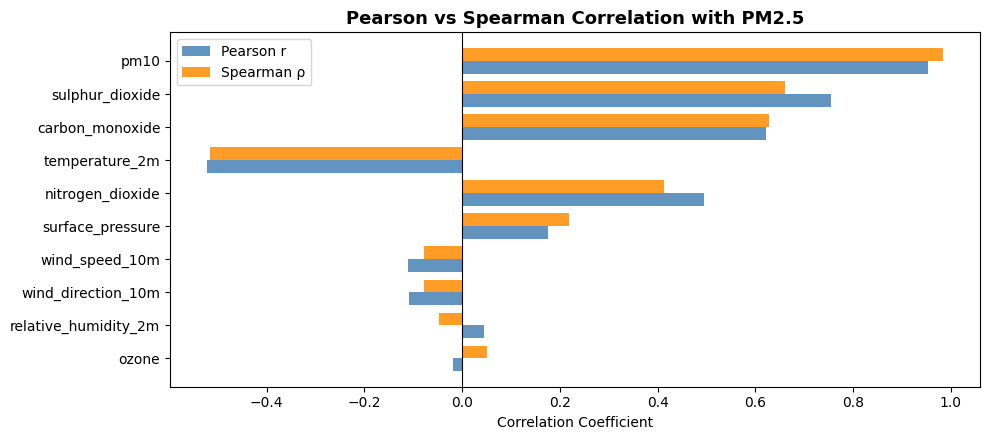

In [5]:
# SPEARMAN VS PEARSON CORRELATION

spearman_results = []
for col in feature_cols:
    valid   = data[[TARGET, col]].dropna()
    rho, p  = stats.spearmanr(valid[TARGET], valid[col])
    spearman_results.append({
        'Feature': col, 'Spearman ρ': rho, 'p-value': p,
        'Significant': '✓' if p < 0.05 else '✗',
    })

spearman_df = (
    pd.DataFrame(spearman_results)
    .sort_values('Spearman ρ', key=abs, ascending=False)
    .reset_index(drop=True)
)
print(spearman_df.to_string(index=False))

# Pearson vs Spearman side-by-side comparison
compare = pearson_df[['Feature', 'Pearson r']].merge(
    spearman_df[['Feature', 'Spearman ρ']], on='Feature'
)
compare = compare.sort_values('Pearson r', key=abs, ascending=True)

y     = np.arange(len(compare))
width = 0.38
fig, ax = plt.subplots(figsize=(10, max(4, len(compare) * 0.45)))
ax.barh(y - width / 2, compare['Pearson r'],  width, label='Pearson r',  color='steelblue',  alpha=0.85)
ax.barh(y + width / 2, compare['Spearman ρ'], width, label='Spearman ρ', color='darkorange', alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(compare['Feature'])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation Coefficient')
ax.set_title('Pearson vs Spearman Correlation with PM2.5', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

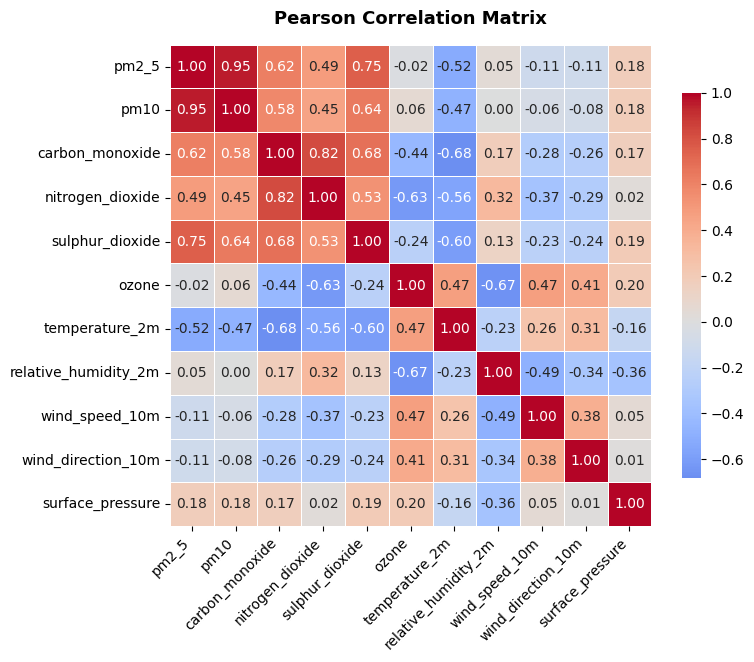

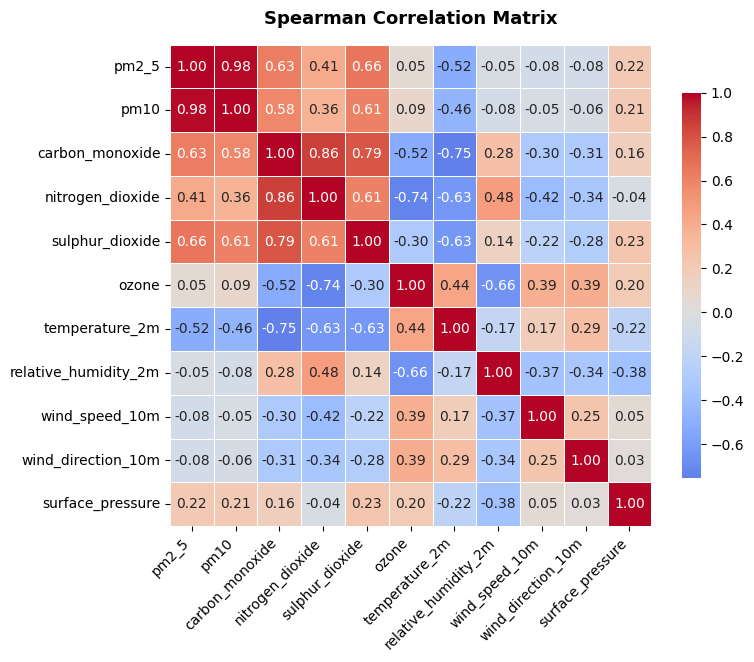

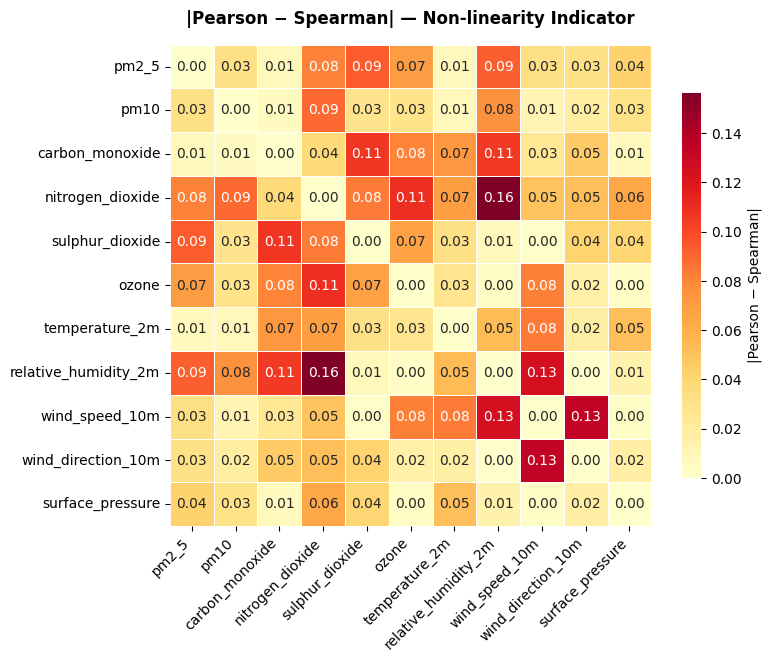

In [6]:
# CORRELATION HEATMAPS

all_cols     = [TARGET] + feature_cols
corr_pearson = data[all_cols].corr(method='pearson')

fig_size = (max(8, len(all_cols) * 0.7), max(6, len(all_cols) * 0.6))

# Pearson heatmap
fig, ax = plt.subplots(figsize=fig_size)
sns.heatmap(
    corr_pearson,
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='white', square=True,
    cbar_kws={'shrink': 0.8}, ax=ax,
)
ax.set_title('Pearson Correlation Matrix', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Spearman heatmap
corr_spearman = data[all_cols].corr(method='spearman')
fig, ax = plt.subplots(figsize=fig_size)
sns.heatmap(
    corr_spearman,
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='white', square=True,
    cbar_kws={'shrink': 0.8}, ax=ax,
)
ax.set_title('Spearman Correlation Matrix', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

divergence = (corr_pearson - corr_spearman).abs()
fig, ax = plt.subplots(figsize=fig_size)
sns.heatmap(
    divergence,
    annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white', square=True,
    cbar_kws={'shrink': 0.8, 'label': '|Pearson − Spearman|'}, ax=ax,
)
ax.set_title('|Pearson − Spearman| — Non-linearity Indicator',
             fontsize=12, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


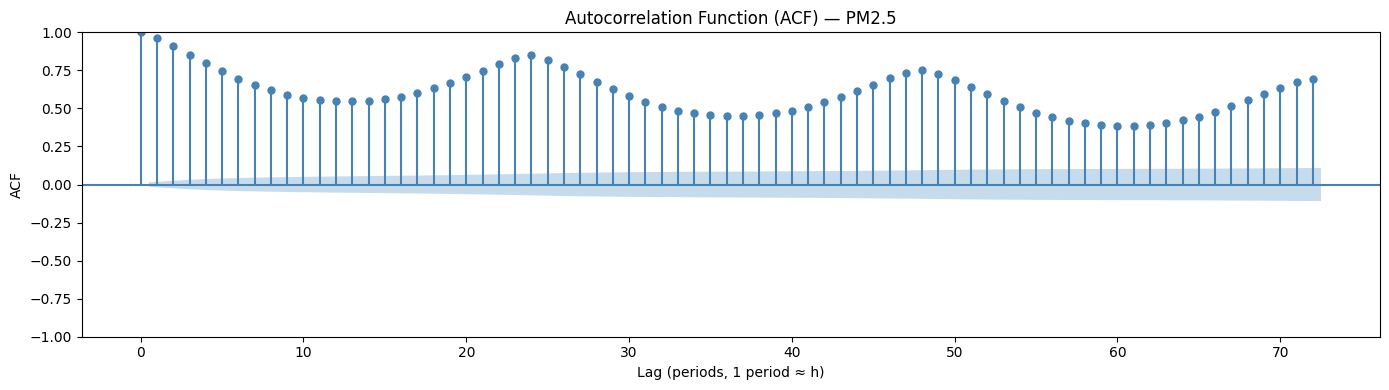

Significant lags (outside 95% CI): 0
Empty DataFrame
Columns: []
Index: []


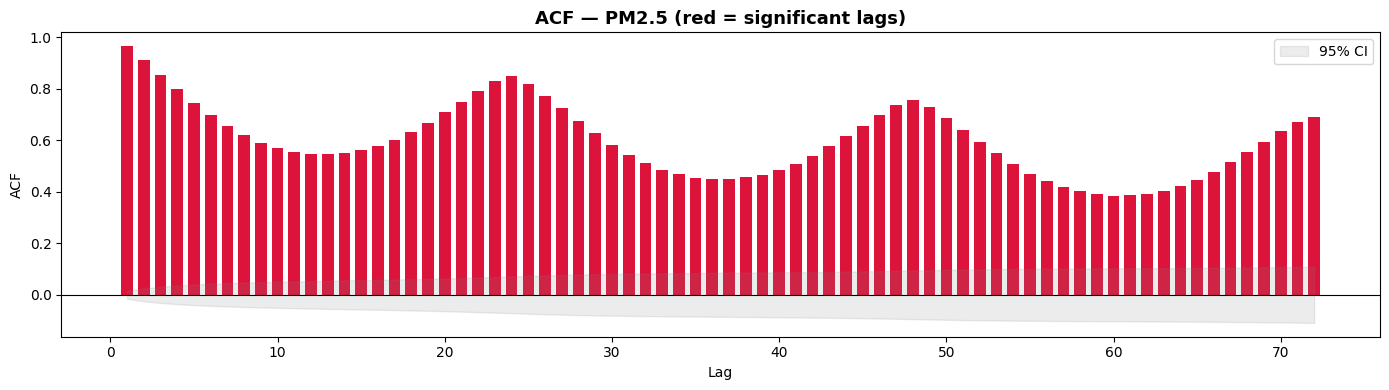


Top 10 significant lags by |ACF|:


KeyError: 'ACF'

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# 7. AUTOCORRELATION FUNCTION (ACF)
# ══════════════════════════════════════════════════════════════════════════════

MAX_LAGS = min(72, len(pm25_series) // 3)  # up to 72 hours for hourly data

# statsmodels ACF plot
fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(pm25_series.dropna(), lags=MAX_LAGS, alpha=0.05, ax=ax,
         title='Autocorrelation Function (ACF) — PM2.5', color='steelblue',
         vlines_kwargs={'colors': 'steelblue'})
ax.set_xlabel(f'Lag (periods, 1 period ≈ {inferred_freq})')
ax.set_ylabel('ACF')
plt.tight_layout()
plt.show()

# Significant lags table
acf_values, conf_int = acf(pm25_series.dropna(), nlags=MAX_LAGS, alpha=0.05)

sig_lags = [
    {
        'Lag': i,
        'ACF': round(acf_values[i], 4),
        'CI Lower': round(conf_int[i, 0], 4),
        'CI Upper': round(conf_int[i, 1], 4),
    }
    for i in range(1, len(acf_values))
    if acf_values[i] > conf_int[i, 1] or acf_values[i] < conf_int[i, 0]
]

sig_df = pd.DataFrame(sig_lags)
print(f'Significant lags (outside 95% CI): {len(sig_df)}')
print(sig_df.head(20).to_string(index=False))

# ACF bar chart coloured by significance
lags_range     = np.arange(1, len(acf_values))
threshold      = conf_int[1:, 1] - acf_values[1:]  # approximate symmetric CI width
is_significant = np.abs(acf_values[1:]) > threshold

fig, ax = plt.subplots(figsize=(14, 4))
bar_colors = ['crimson' if s else 'lightsteelblue' for s in is_significant]
ax.bar(lags_range, acf_values[1:], color=bar_colors, width=0.7)
ax.fill_between(lags_range,
                conf_int[1:, 0] - acf_values[1:],
                conf_int[1:, 1] - acf_values[1:],
                alpha=0.15, color='grey', label='95% CI')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
ax.set_title('ACF — PM2.5 (red = significant lags)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 10 significant lags by |ACF|:')
print(
    sig_df.sort_values('ACF', key=abs, ascending=False)
    .head(10)
    .reset_index(drop=True)
    .to_string(index=False)
)

In [ ]:
# SUMMARY

print('=' * 60)
print('  EDA SUMMARY — Kathmandu PM2.5 (2023–2024)')
print('=' * 60)

print(f'\n[1] Decomposition')
print(f'    Trend strength   : {F_trend:.3f}')
print(f'    Seasonal strength: {F_season:.3f}')

print(f'\n[2] Stationarity')
print(f'    Raw — ADF stationary : {adf_raw}')
print(f'    Raw — KPSS stationary: {kpss_raw}')
print(f'    Differencing required: {not (adf_raw and kpss_raw)}')

top_pearson  = pearson_df.iloc[0]
top_spearman = spearman_df.iloc[0]
print(f'\n[3] Top Pearson  correlate: {top_pearson["Feature"]} (r={top_pearson["Pearson r"]:.3f})')
print(f'[4] Top Spearman correlate: {top_spearman["Feature"]} (ρ={top_spearman["Spearman ρ"]:.3f})')

print(f'\n[5] Significant ACF lags: {len(sig_df)}')
if not sig_df.empty:
    top_lags = sig_df.sort_values('ACF', key=abs, ascending=False).head(5)['Lag'].tolist()
    print(f'    Top lags (by |ACF|) : {top_lags}')


  EDA SUMMARY — Kathmandu PM2.5 (2023–2024)

[1] Decomposition
    Trend strength   : 0.900
    Seasonal strength: 0.738

[2] Stationarity
    Raw — ADF stationary : True
    Raw — KPSS stationary: False
    Differencing required: True

[3] Top Pearson  correlate: pm10 (r=0.952)
[4] Top Spearman correlate: pm10 (ρ=0.984)

[5] Significant ACF lags: 0
